In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier,VotingClassifier
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score,accuracy_score
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


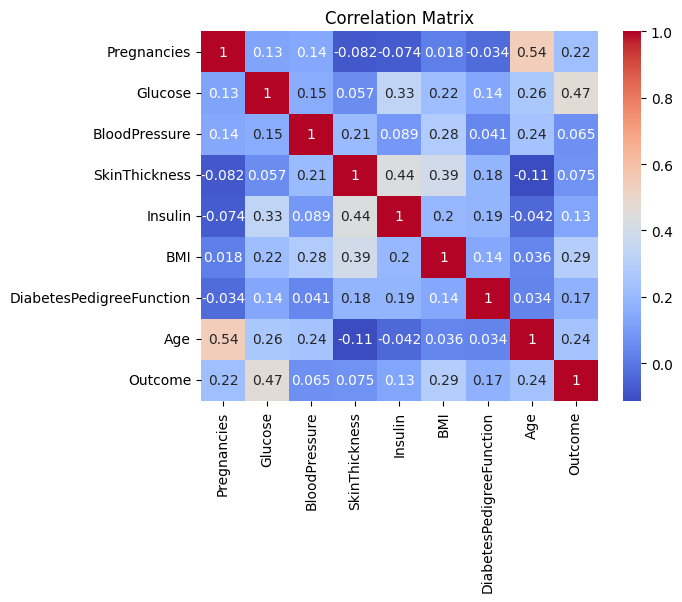

In [4]:
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


print("mean before scaling:", X_train_raw.mean())
print("mean after scaling:", X_train.mean())

mean before scaling: Pregnancies                   3.742671
Glucose                     120.855049
BloodPressure                69.415309
SkinThickness                20.399023
Insulin                      81.438111
BMI                          31.983388
DiabetesPedigreeFunction      0.469168
Age                          32.907166
dtype: float64
mean after scaling: -3.797179725916659e-17


In [8]:
lr = LogisticRegression(
    l1_ratio=0.5,
    random_state=42,
    solver='saga',
    max_iter=10000
)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("precision:", precision_score(y_test, y_pred_lr))
print("recall:", recall_score(y_test, y_pred_lr))
print("f1 score:", f1_score(y_test, y_pred_lr))
print("roc auc score:", roc_auc_score(y_test, y_pred_lr))
print("accuracy train:", accuracy_score(y_train, lr.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_lr))

confusion matrix:
 [[79 20]
 [18 37]]
precision: 0.6491228070175439
recall: 0.6727272727272727
f1 score: 0.6607142857142857
roc auc score: 0.7353535353535354
accuracy train: 0.7687296416938111
accuracy test: 0.7532467532467533


In [9]:
lr_gs = LogisticRegression()
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
    'max_iter': [100, 500, 1000],
    'solver': ['saga'],
    'random_state': [42]
}

grid_search_lr = GridSearchCV(estimator=lr_gs, param_grid=lr_params, cv=5, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)
y_pred_lr_grid = grid_search_lr.predict(X_test)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)

Best parameters for Logistic Regression: {'C': 0.1, 'l1_ratio': 0.25, 'max_iter': 100, 'random_state': 42, 'solver': 'saga'}


In [10]:
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_lr_grid))
print("precision:", precision_score(y_test, y_pred_lr_grid))
print("recall:", recall_score(y_test, y_pred_lr_grid))
print("f1 score:", f1_score(y_test, y_pred_lr_grid))
print("roc auc score:", roc_auc_score(y_test, y_pred_lr_grid))
print("accuracy train:", accuracy_score(y_train, grid_search_lr.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_lr_grid))


confusion matrix:
 [[83 16]
 [19 36]]
precision: 0.6923076923076923
recall: 0.6545454545454545
f1 score: 0.6728971962616822
roc auc score: 0.7464646464646464
accuracy train: 0.760586319218241
accuracy test: 0.7727272727272727


In [11]:
svc = SVC(kernel='rbf', random_state=42, C=1, probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("confusion matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("precision:", precision_score(y_test, y_pred_svc))    
print("recall:", recall_score(y_test, y_pred_svc))
print("f1 score:", f1_score(y_test, y_pred_svc))
print("roc auc score:", roc_auc_score(y_test, y_pred_svc))
print("accuracy train:", accuracy_score(y_train, svc.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_svc))

confusion matrix:
 [[82 17]
 [24 31]]
precision: 0.6458333333333334
recall: 0.5636363636363636
f1 score: 0.6019417475728155
roc auc score: 0.6959595959595959
accuracy train: 0.8338762214983714
accuracy test: 0.7337662337662337


In [12]:
svc_gs = SVC(probability=True)
svc_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'random_state': [42]
}

grid_search_svc = GridSearchCV(estimator=svc_gs, param_grid=svc_params, cv=5, n_jobs=-1)
grid_search_svc.fit(X_train, y_train)
y_pred_svc_grid = grid_search_svc.predict(X_test)
print("Best parameters for SVC:", grid_search_svc.best_params_)

Best parameters for SVC: {'C': 1, 'kernel': 'rbf', 'random_state': 42}


In [13]:
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_svc_grid))
print("precision:", precision_score(y_test, y_pred_svc_grid))
print("recall:", recall_score(y_test, y_pred_svc_grid))
print("f1 score:", f1_score(y_test, y_pred_svc_grid))
print("roc auc score:", roc_auc_score(y_test, y_pred_svc_grid))
print("accuracy train:", accuracy_score(y_train, grid_search_svc.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_svc_grid))


confusion matrix:
 [[82 17]
 [24 31]]
precision: 0.6458333333333334
recall: 0.5636363636363636
f1 score: 0.6019417475728155
roc auc score: 0.6959595959595959
accuracy train: 0.8338762214983714
accuracy test: 0.7337662337662337


In [14]:
dt = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=5,
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("precision:", precision_score(y_test, y_pred_dt))
print("recall:", recall_score(y_test, y_pred_dt))
print("f1 score:", f1_score(y_test, y_pred_dt))
print("roc auc score:", roc_auc_score(y_test, y_pred_dt))
print("accuracy train:", accuracy_score(y_train, dt.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_dt))

confusion matrix:
 [[87 12]
 [20 35]]
precision: 0.7446808510638298
recall: 0.6363636363636364
f1 score: 0.6862745098039216
roc auc score: 0.7575757575757576
accuracy train: 0.8420195439739414
accuracy test: 0.7922077922077922


In [15]:
dt_gs = DecisionTreeClassifier()
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'random_state': [42]
}

grid_search_dt = GridSearchCV(estimator=dt_gs, param_grid=dt_params, cv=5, n_jobs=-1)
grid_search_dt.fit(X_train, y_train)
y_pred_dt_grid = grid_search_dt.predict(X_test)
print("Best parameters for Decision Tree:", grid_search_dt.best_params_)

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 5, 'random_state': 42}


In [16]:
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_dt_grid))
print("precision:", precision_score(y_test, y_pred_dt_grid))
print("recall:", recall_score(y_test, y_pred_dt_grid))
print("f1 score:", f1_score(y_test, y_pred_dt_grid))
print("roc auc score:", roc_auc_score(y_test, y_pred_dt_grid))
print("accuracy train:", accuracy_score(y_train, grid_search_dt.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_dt_grid))


confusion matrix:
 [[87 12]
 [20 35]]
precision: 0.7446808510638298
recall: 0.6363636363636364
f1 score: 0.6862745098039216
roc auc score: 0.7575757575757576
accuracy train: 0.8420195439739414
accuracy test: 0.7922077922077922


In [17]:
lr_vc = LogisticRegression(C=0.1, l1_ratio=0.25, max_iter=100, random_state=42, solver='saga')
svc_vc = SVC(C=1, kernel='rbf', random_state=42, probability=True)
dt_vc = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', lr_vc), ('svc', svc_vc), ('dt', dt_vc)],
    voting='soft'   
)
voting_clf.fit(X_train, y_train)
y_pred_vc = voting_clf.predict(X_test)

print("confusion matrix:\n", confusion_matrix(y_test, y_pred_vc))
print("precision:", precision_score(y_test, y_pred_vc))
print("recall:", recall_score(y_test, y_pred_vc))
print("f1 score:", f1_score(y_test, y_pred_vc))
print("roc auc score:", roc_auc_score(y_test, y_pred_vc))
print("accuracy train:", accuracy_score(y_train, voting_clf.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_vc))


confusion matrix:
 [[85 14]
 [20 35]]
precision: 0.7142857142857143
recall: 0.6363636363636364
f1 score: 0.6730769230769231
roc auc score: 0.7474747474747474
accuracy train: 0.8469055374592834
accuracy test: 0.7792207792207793


In [ ]:
dt_ada = DecisionTreeClassifier(max_depth=1, random_state=42)

ada_clf = AdaBoostClassifier(
    estimator=dt_ada,
    n_estimators=50,
    random_state=42
)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("precision:", precision_score(y_test, y_pred_ada))
print("recall:", recall_score(y_test, y_pred_ada))
print("f1 score:", f1_score(y_test, y_pred_ada))
print("roc auc score:", roc_auc_score(y_test, y_pred_ada))
print("accuracy train:", accuracy_score(y_train, ada_clf.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_ada))

confusion matrix:
 [[77 22]
 [21 34]]
precision: 0.6071428571428571
recall: 0.6181818181818182
f1 score: 0.6126126126126126
roc auc score: 0.697979797979798
accuracy train: 0.8729641693811075
accuracy test: 0.7207792207792207


In [24]:
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("precision:", precision_score(y_test, y_pred_xgb))
print("recall:", recall_score(y_test, y_pred_xgb))
print("f1 score:", f1_score(y_test, y_pred_xgb))
print("roc auc score:", roc_auc_score(y_test, y_pred_xgb))
print("accuracy train:", accuracy_score(y_train, xgb_clf.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_xgb))

confusion matrix:
 [[77 22]
 [18 37]]
precision: 0.6271186440677966
recall: 0.6727272727272727
f1 score: 0.6491228070175439
roc auc score: 0.7252525252525254
accuracy train: 0.9039087947882736
accuracy test: 0.7402597402597403


In [25]:
xgb_gs = XGBClassifier(eval_metric='logloss')
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'random_state': [42]
}
grid_search_xgb = GridSearchCV(estimator=xgb_gs, param_grid=xgb_params, cv=5, n_jobs=-1)
grid_search_xgb.fit(X_train, y_train)
y_pred_xgb_grid = grid_search_xgb.predict(X_test)
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)

Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'random_state': 42}


In [26]:
print("confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb_grid))
print("precision:", precision_score(y_test, y_pred_xgb_grid))   
print("recall:", recall_score(y_test, y_pred_xgb_grid))
print("f1 score:", f1_score(y_test, y_pred_xgb_grid))
print("roc auc score:", roc_auc_score(y_test, y_pred_xgb_grid))
print("accuracy train:", accuracy_score(y_train, grid_search_xgb.predict(X_train)))
print("accuracy test:", accuracy_score(y_test, y_pred_xgb_grid))


confusion matrix:
 [[80 19]
 [19 36]]
precision: 0.6545454545454545
recall: 0.6545454545454545
f1 score: 0.6545454545454545
roc auc score: 0.7313131313131312
accuracy train: 0.8599348534201955
accuracy test: 0.7532467532467533
